# Hybrid FMU Integration: Event-Driven Pendulum Simulation

This tutorial demonstrates how to extend the `FMUComponent` class in `syssimx` with **hybrid simulation capabilities** using state rollback and explicit event handling.

We implement a custom `FMUPendulum` component that bridges continuous FMU dynamics with discrete event detection and handling. The main goal is to show how the `HybridAlgorithm` in `syssimx` enables accurate event localization through rollback mechanisms, without requiring globally small communication step sizes.

## Overview

This tutorial builds on tutorial 02 and 03, where we observed that:

1. FMU co-simulation detects events only at macro communication time steps.
2. Reducing `dt` globally improves event accuracy but increases computational cost.
3. Direct `getFMUstate`/`setFMUstate` rollback can preserve simulation state for Euler FMUs.

Here, we implement a **hybrid FMU wrapper** that combines:

- **Event indicators**: Zero-crossing functions for continuous event detection (`theta <= 0` for wall contact).
- **Snapshot/restore**: State rollback via `getFMUstate`/`setFMUstate` (Euler) or full reinitialization (CVode).
- **Event handling**: Discrete state updates (velocity inversion) triggered by detected events.
- **Hybrid algorithm**: Automatic event localization and iterative refinement through rollback.

The workflow is:

1. Define a simple `Pendulum.mo` model (continuous dynamics only, no built-in events).
2. Export FMUs with Euler and CVode solvers.
3. Extend `FMUComponent` into `FMUPendulum` with hybrid capabilities.
4. Configure event indicators (`wall_hit`) and event connections within a `System`.
5. Run simulations and compare Euler vs CVode performance and accuracy.

This demonstrates how external hybrid logic can be layered on top of standard FMUs without modifying the Modelica source code.

```Modelica
model Pendulum  
  // Imports
  import Modelica.Constants.pi;

  // Parameters
  parameter Real m(unit="kg") = 40;
  parameter Real L(unit="m") = 0.6;
  parameter Real theta0(unit="rad") = 0;
  parameter Real omega0(unit="rad/s") = 0;
  parameter Real g(unit="m/s2") = 9.81;
  parameter Real inertia(unit="kg.m2") = 20;
  
  // Input torque at the pivot
  Modelica.Blocks.Interfaces.RealInput torque(unit="N.m");

  // Outputs
  Modelica.Blocks.Interfaces.RealOutput theta(unit="rad");
  Modelica.Blocks.Interfaces.RealOutput omega(unit="rad/s");
  Modelica.Blocks.Interfaces.RealOutput alpha(unit="rad/s2") = der(omega);

initial equation
  theta = theta0;
  omega = omega0;

equation
  der(theta) = omega;
  der(omega) = -(m * g * L / inertia) * sin(theta) + torque / inertia;
end Pendulum;

## Learning Goals

- Understand how to extend `FMUComponent` with custom hybrid simulation capabilities.
- Implement event indicators as zero-crossing functions for external event detection.
- Use `snapshot_state` and `restore_state` methods to enable rollback for event localization.
- Handle discrete state transitions externally via `_handle_events_internal`.
- Configure `System` with event connections and the `HybridAlgorithm`.
- Compare Euler vs CVode solver behavior under hybrid rollback scenarios.
- Analyze computational performance trade-offs between solver choice and event localization accuracy.

## Prerequisites and Setup

This tutorial requires:

- OpenModelica + `OMPython` for FMU export
- `syssimx` with `FMUComponent`, `System`, and `HybridAlgorithm`
- Standard Python stack: `numpy`, `matplotlib`

We assume familiarity with:

- Basic FMU co-simulation (tutorial 01)
- Event sensitivity and macro step size effects (tutorial 02)
- FMU state rollback mechanisms (tutorial 03)

The Modelica model used here is `Pendulum.mo`, which contains **only continuous dynamics** (no built-in `when`/`reinit` events). All event detection and handling is implemented externally in the Python wrapper.

In [19]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from syssimx import FMUComponent

## Modelica Model and FMU Export

We use a simple pendulum model (`Pendulum.mo`) with:

- **Continuous dynamics**: $\dot{\theta} = \omega$, $\dot{\omega} = -(mgL/I)\sin(\theta) + \tau/I$
- **Parameters**: `theta0`, `omega0` (initial conditions), `m`, `L`, `inertia`, `g`
- **No built-in events**: Unlike tutorial 02's `PendulumDiscreteContact`, this model contains no `when` clauses or `reinit` statements

We export two FMI 2.0 Co-Simulation FMUs:

- **Euler**: Fixed-step explicit Euler integration (simple, supports `getFMUstate`/`setFMUstate`)
- **CVode**: Variable-step BDF solver (higher accuracy, limited rollback support)

The `export_fmu` function below uses OpenModelica's `--fmiFlags=s:solver` option to specify the internal solver and returns the path to the exported FMU.

In [20]:
model_file = Path("docs/04_tool_integration/01_modelica/models/Pendulum.mo")

def export_fmu(solver: str) -> str:
    model = ModelicaSystem(
        fileName=str(model_file),
        modelName="Pendulum",
        commandLineOptions=[f"--fmiFlags=s:{solver}", "-d=fmuExperimental"],
    )
    model.buildModel()
    temp_path = model.convertMo2Fmu(version="2.0", fmuType="cs")
    temp_path = Path(temp_path)
    dest_path = Path("docs/04_tool_integration/01_modelica/fmus") / ('pendulum_' + f"{solver}.fmu")
    if dest_path.exists():
        dest_path.unlink()
    temp_path.rename(dest_path)
    return str(dest_path)


fmu_paths = {
    "euler": export_fmu("euler"),
    "cvode": export_fmu("cvode"),
}

## Hybrid Extensions: The `FMUPendulum` Class

To enable hybrid simulation, we extend `FMUComponent` with three key capabilities:

### 1. State Snapshot and Restore

The `snapshot_state()` and `restore_state(snapshot, t)` methods implement rollback:

- **Euler FMU**: Uses native `getFMUstate()` / `setFMUstate()` from FMI 2.0. Parameters must be reapplied after restore via `_apply_parameters_starts()` (see tutorial 03).
- **CVode FMU**: Does not reliably support state restoration. Instead, we save the continuous state (`theta`, `omega`) and reinitialize the FMU from scratch at the restored time with updated initial conditions.

### 2. Event Indicators

Event indicators are zero-crossing functions $g(\mathbf{x}, t)$ that signal discrete events. For wall contact at $\theta = 0$:

$$
g(\theta, \omega, t) = \theta
$$

When $g$ crosses zero in the negative direction ($\dot{g} < 0$), the `HybridAlgorithm` detects the event and triggers localization through rollback.

### 3. Event Handling

The `_handle_events_internal(event_names, t)` method executes discrete state updates:

- When `"wall_hit"` is detected, we invert the velocity: $\omega^+ = -\epsilon \omega^-$ (with restitution coefficient $\epsilon = 1$ for elastic collision).
- The FMU is reinitialized with the updated state at the event time.

### Internal Step Subdivision (Euler Only)

For the Euler FMU, the `_do_step_internal()` method subdivides macro steps into smaller internal steps ($dt_{\text{internal}} = 10^{-4}$). This improves numerical accuracy while maintaining coarse macro communication steps for event detection.

The class definition below implements these extensions:

In [21]:
from syssimx.core.port import PortSpec, PortType

class FMUPendulum(FMUComponent):
    def __init__(self, name: str = "Pendulum", solver: str = "euler"):
        fmu_path = fmu_paths[solver]
        self.solver = solver
        super().__init__(name, fmu_path, group="Mechanical")

        self.input_specs.update({
            "omega_invert": PortSpec("omega_invert", PortType.EVENT, "in")
        })

    def _do_step_internal(self, t, dt):
        if self.solver == "euler":
            t_right = t + dt
            while t < t_right - 1e-12:
                dt_internal = min(1e-4, t_right - t)
                super()._do_step_internal(t, dt_internal)
                t += dt_internal
        else:
            super()._do_step_internal(t, dt)

    def snapshot_state(self):
        if self.solver == "euler":
            return self._instance.getFMUstate()
        else:
            return super().get_state()
        
    def restore_state(self, snapshot, t):
        self.t = t
        if self.solver == "euler":
            self._instance.setFMUstate(snapshot)
            self._apply_parameters_starts()
        else:
            theta0 = snapshot['theta']['value']
            omega0 = snapshot['omega']['value']
            self._instance.reset()
            self._instance.instantiate()
            self._instance.setupExperiment(startTime=t)
            self._instance.enterInitializationMode()
            self.set_parameters(**{"theta0": theta0, "omega0": omega0})
            self._apply_parameters_starts()
            self._apply_input_starts()
            self._instance.exitInitializationMode()
        self._update_output_states(t)
        self._record_outputs(t)

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        restitution = 1
        output = self.get_outputs()
        theta0 = output["theta"].magnitude
        omega0 = -restitution * output["omega"].magnitude

        self._instance.reset()
        self._instance.instantiate()
        self._instance.setupExperiment(startTime=t)
        self._instance.enterInitializationMode()
        self.set_parameters(**{"theta0": theta0, "omega0": omega0})
        self._apply_parameters_starts()
        self._apply_input_starts()
        self._instance.exitInitializationMode()


    def _update_output_states(
            self, t: float | None = None, event_names: list[str] | None = []
    ):
        super()._update_output_states(t)
        if event_names:
            for event_name in event_names:
                if event_name in self.output_specs.keys():
                    self.outputs[event_name].set(value=True, t=t)
        else:
            for out_port in self.outputs.values():
                if out_port.spec.type == PortType.EVENT:
                    out_port.set(value=False, t=t)


## Component Instantiation

We create two `FMUPendulum` instances (one for each solver) and set initial conditions:

- $\theta_0 = 0.5$ rad (pendulum starts at positive angle)
- $\omega_0 = 0.0$ rad/s (released from rest)

This configuration causes the pendulum to swing down and cross $\theta = 0$ (the wall position), triggering a contact event.

In [22]:
euler_pendulum = FMUPendulum("Pendulum_Euler", solver="euler")
cvode_pendulum = FMUPendulum("Pendulum_CVODE", solver="cvode")

euler_pendulum.set_parameters(theta0=0.5, omega0=0.0)
cvode_pendulum.set_parameters(theta0=0.5, omega0=0.0)

## Event Indicator and Connection Setup

### Event Indicator Definition

We define a zero-crossing function `wall_hit_indicator` that returns the pendulum angle $\theta$. The event is triggered when:

- $\theta$ crosses zero in the **negative direction** (`direction=-1`)
- This corresponds to the pendulum swinging from positive to negative angles

The `add_event_indicator` method registers this function with the component, enabling the `HybridAlgorithm` to monitor it during simulation.

### Event Connection

The `EventConnection` creates a feedback loop:

- **Source**: `wall_hit` event output from the pendulum
- **Destination**: `omega_invert` event input on the same pendulum

When the event is detected and localized, the connection triggers `_handle_events_internal()`, which reinitializes the pendulum with inverted velocity.

In [23]:
from syssimx.system.connection import EventConnection

def wall_hit_indicator(comp: FMUPendulum) -> float:
    return comp.get_outputs()["theta"].magnitude

euler_pendulum.add_event_indicator(
    name="wall_hit", func=wall_hit_indicator, direction=-1,
)

cvode_pendulum.add_event_indicator(
    name="wall_hit", func=wall_hit_indicator, direction=-1,
)

event_conn_euler = EventConnection(
    src_comp=euler_pendulum.name,
    src_port="wall_hit",
    dst_comp=euler_pendulum.name,
    dst_port="omega_invert"
)

event_conn_cvode = EventConnection(
    src_comp=cvode_pendulum.name,
    src_port="wall_hit",
    dst_comp=cvode_pendulum.name,
    dst_port="omega_invert"
)

## System Initialization and Visualization

We create a `System` instance and add:

1. The `FMUPendulum` component
2. The event connection (self-loop for event handling)

The `HybridAlgorithm` is automatically selected when event indicators are present. The system graph visualization shows:

- Component nodes (pendulum)
- Event connection edges (wall_hit → omega_invert)

This architecture enables the hybrid simulation loop:

1. Integrate continuous dynamics with macro step `dt`
2. Evaluate event indicators at each step
3. If zero-crossing detected: rollback, bisect, localize event time
4. Execute event handler, reinitialize FMU
5. Continue integration

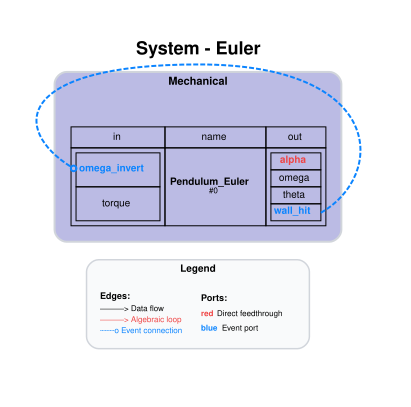

In [24]:
from syssimx import System
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

system_euler = System(name="System - Euler")
system_euler.add_component(euler_pendulum)
system_euler.add_event_connection(event_conn_euler)
system_euler.initialize(t0=0.0)
visualizer_euler = SystemGraphVisualizer(system_euler)
visualizer_euler.visualize()

## Hybrid Algorithm Configuration

The `HybridAlgorithm` parameters control event localization accuracy:

- `record_internal_steps = False`: Only record macro communication steps (not rollback iterations)
- `tol_time = 1e-9`: Event time localization tolerance (bisection stops when $|t_{\text{left}} - t_{\text{right}}| < 10^{-9}$ s)
- `tol_value = 1e-9`: Event indicator value tolerance (accept event when $|g(t)| < 10^{-9}$)

These tight tolerances ensure precise event detection, at the cost of more rollback iterations per event.

In [25]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

In [26]:
system_euler.algorithm.record_internal_steps = False
system_euler.algorithm.tol_time = 1e-9
system_euler.algorithm.tol_value = 1e-9

t0 = 0.0
tf = 1.0
dt = 0.05
system_euler.run(t0, tf, dt)

[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.450000, 0.500000]: Pendulum_Euler.wall_hit
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Indicators at left  (t=0.45000000): {'Pendulum_Euler': {'wall_hit': 0.025595701207108773}}
[hybrid] DEBUG: Indicators at right (t=0.50000000): {'Pendulum_Euler': {'wall_hit': -0.059159615386525116}}
[hybrid] DEBUG: Indicator Pendulum_Euler.wall_hit = -7.5429e-10
[hybrid] INFO: Event located at t=0.46507956
[hybrid] DEBUG:   Events at located time: Pendulum_Euler.wall_hit
[hybrid] INFO: Handling 1 event(s) at t=0.46507956, micro=0: Pendulum_Euler.wall_hit
[hybrid] DEBUG: Events grouped by listener: {'Pendulum_Euler': ['wall_hit']}
[hybrid] INFO: ================================================================================


### Euler Results: Event Detection Summary

The plot below visualizes the simulation trajectory with event markers.

In [29]:
history = system_euler.get_history()

t_vals, data = history["Pendulum_Euler"]
theta_vals = data["theta"]
omega_vals = data["omega"]

event_history = system_euler.history.get_all_event_histories()
zero_crossings = event_history.get((euler_pendulum.name, "wall_hit"), [])

event_time = zero_crossings[0].t if zero_crossings else None

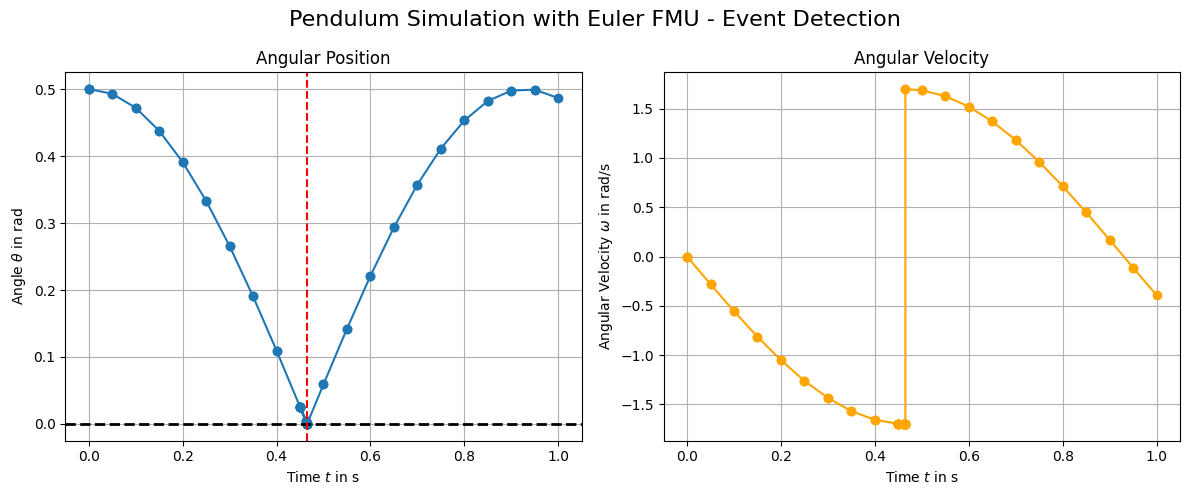

In [28]:
plt.figure(figsize=(12, 5))
plt.suptitle("Pendulum Simulation with Euler FMU - Event Detection", fontsize=16)
plt.subplot(1, 2, 1)
plt.title("Angular Position")
plt.plot(t_vals, theta_vals, label="theta", marker='o')
plt.axhline(0, color='k', linestyle='--', linewidth=2)
plt.axvline(event_time, color='red', linestyle='--', label='Detected Event (theta=0)')
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Angle $\theta$ in rad")
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Angular Velocity") 
plt.plot(t_vals, omega_vals, label="omega", color="orange", marker='o')
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Angular Velocity $\omega$ in rad/s")
plt.grid()  
plt.tight_layout()
plt.show()

## Conclusion

This tutorial demonstrated how to extend `FMUComponent` with hybrid simulation capabilities:

1. **External event handling**: We added discrete event logic (wall contact detection and velocity inversion) to a continuous-only Modelica model without modifying the source code.

2. **Rollback implementation**: Two approaches were shown:
   - Euler: Efficient native `getFMUstate`/`setFMUstate`
   - CVode: Full reinitialization workaround (slower, less accurate)

3. **System-level integration**: The `HybridAlgorithm` automatically orchestrates event detection, rollback, bisection, and event handling through a declarative API.

**Recommendations**

- **Use Euler FMUs** for hybrid systems with frequent events when rollback is critical
- **Use CVode FMUs** for stiff continuous systems with infrequent events
- **Internal step subdivision** (as shown in `_do_step_internal`) can improve Euler accuracy without impacting event detection